In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [77]:
df = pd.read_csv('Algerian_forest_fires_dataset.csv',header=1)

In [78]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.0+ KB


In [80]:
df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [81]:
df.isnull().sum()

day            0
month          1
year           1
Temperature    1
 RH            1
 Ws            1
Rain           1
FFMC           1
DMC            1
DC             1
ISI            1
BUI            1
FWI            1
Classes        2
dtype: int64

In [82]:
df = df.dropna().reset_index(drop= True)

In [83]:
df.loc[:122, 'Region'] = 0
df.loc[122:, 'Region'] = 1

In [84]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0.0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0.0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0.0


In [87]:
df.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,01,06,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire,1.0


In [86]:
df= df.drop(122).reset_index(drop = True)

In [88]:
df.loc[:122,'Region'] = 0
df.loc[122:,'Region'] = 1

In [89]:
df[['Region']] = df[["Region"]].astype(int)

In [90]:
df.columns = df.columns.str.strip()

In [91]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [92]:
df[['day', 'month', 'year', 'Temperature', 'RH', 'Ws']] = df[['day', 'month', 'year', 'Temperature', 'RH', 'Ws']].astype(int)

In [93]:
df[['Rain', 'FFMC','DMC', 'DC', 'ISI', 'BUI', 'FWI']] = df[['Rain', 'FFMC','DMC', 'DC', 'ISI', 'BUI', 'FWI']].astype(float)

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    int64  
dtypes: float64(7), int64(7), object(1)
memory usage: 28.6+ KB


In [95]:
df.to_csv('Algerian_forest_fires_cleaned.csv', index=False)

In [96]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [97]:
df.sample(5)


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
127,6,6,2012,35,54,11,0.1,83.7,8.4,26.3,3.1,9.3,3.1,fire,1
9,10,6,2012,28,79,12,0.0,73.2,9.5,46.3,1.3,12.6,0.9,not fire,0
94,3,9,2012,25,78,15,3.8,42.6,1.2,7.5,0.1,1.7,0.0,not fire,0
92,1,9,2012,25,76,17,7.2,46.0,1.3,7.5,0.2,1.8,0.1,not fire,0
211,30,8,2012,34,49,15,0.0,89.2,24.8,159.1,8.1,35.7,16.0,fire,1


In [98]:
df.drop(['day', 'month', 'year'], axis=1, inplace=True)

In [102]:
df['Classes']= np.where(df['Classes'].str.contains('not fire'),0,1)

In [103]:
df.to_csv('Algerian_forest_fires_cleaned(2).csv', index=False)

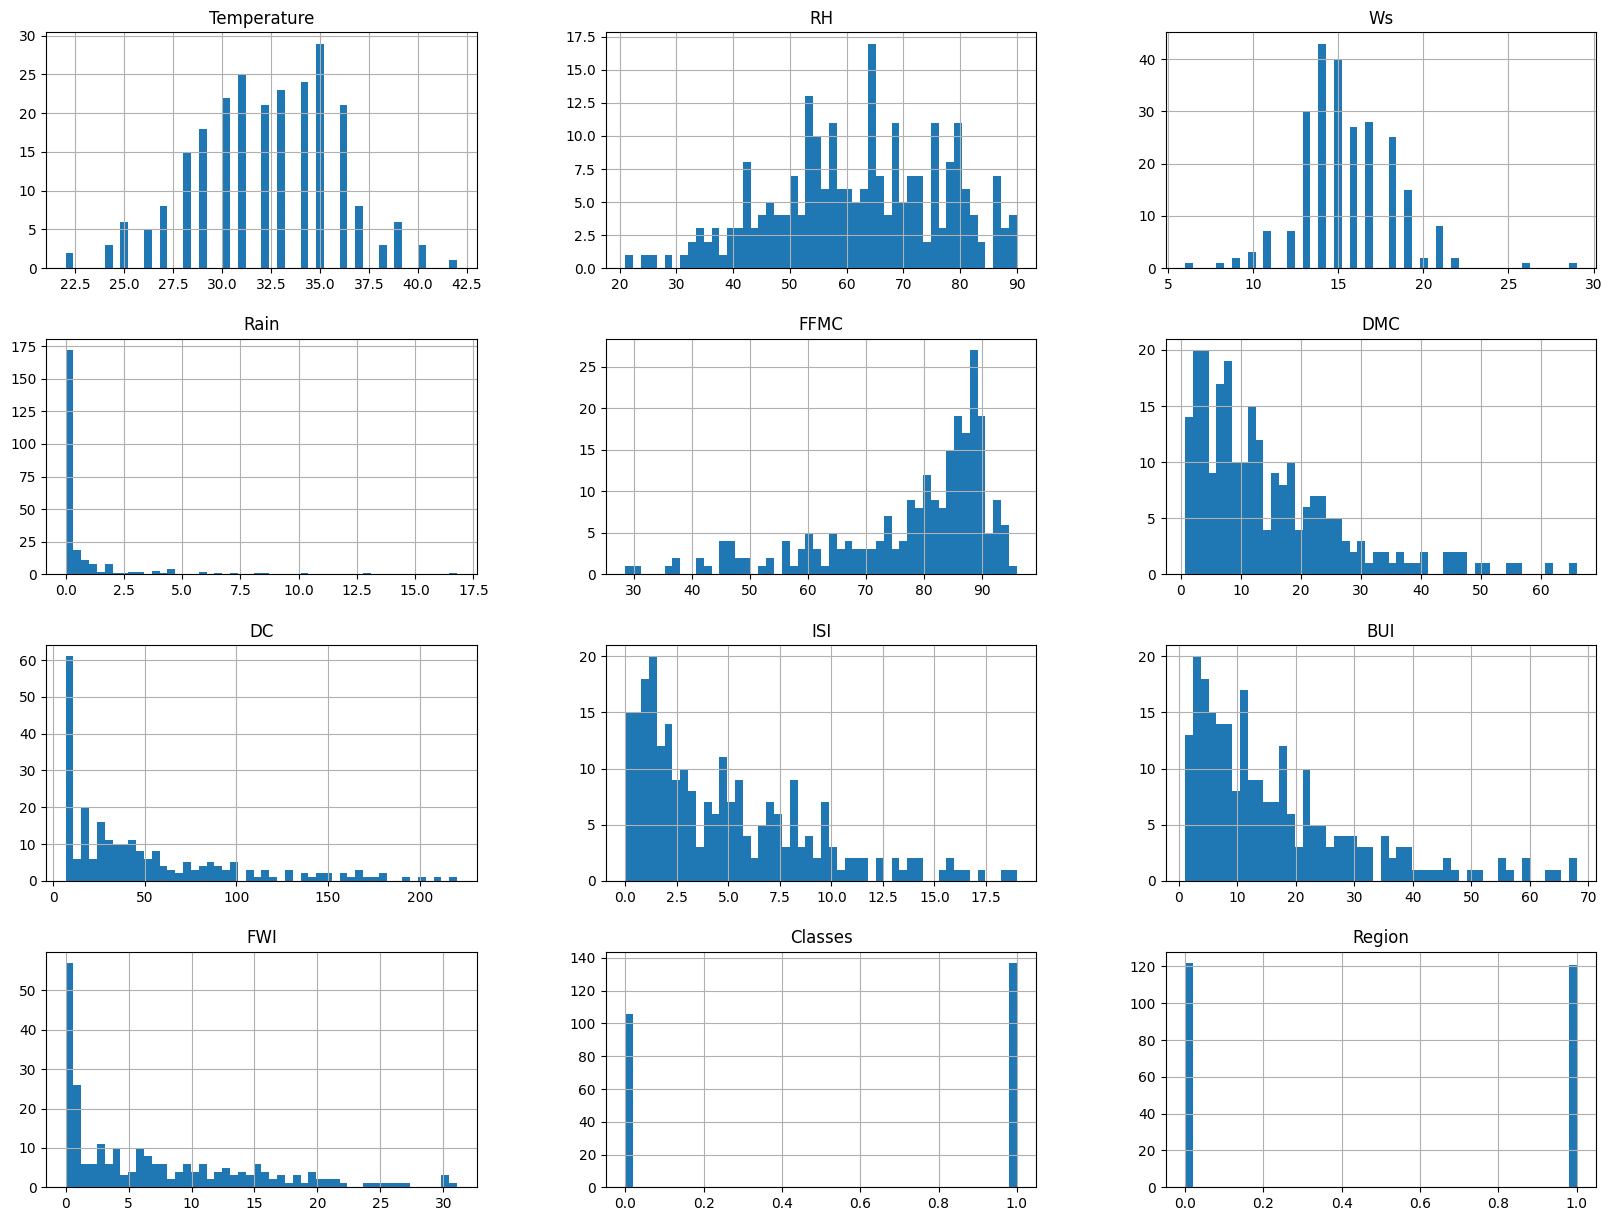

In [104]:
## Plot desnity plot for all features
# plt.style.use('seaborn')
df.hist(bins=50,figsize=(20,15))
plt.show()

<Axes: >

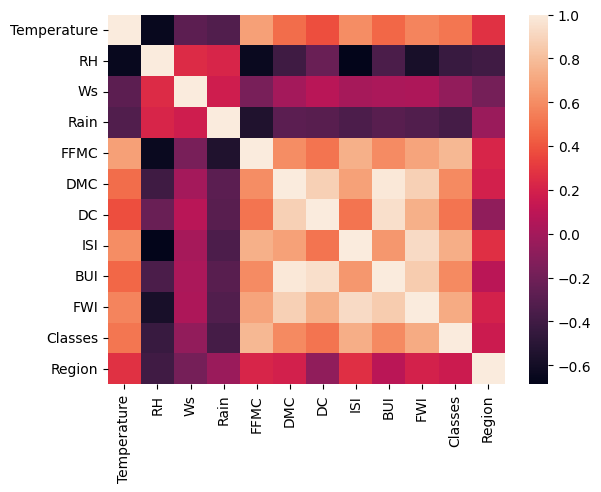

In [105]:
sns.heatmap(df.corr())

In [106]:
X = df.drop('FWI',axis=1)
y=df['FWI']

In [107]:
from sklearn.model_selection import train_test_split


In [108]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [109]:
X_train,X_test.shape

(     Temperature  RH  Ws  Rain  FFMC   DMC     DC   ISI   BUI  Classes  Region
 115           29  65  19   0.6  68.3   5.5   15.2   1.5   5.8        0       0
 207           33  37  16   0.0  92.2  61.3  167.2  13.1  64.0        1       1
 158           38  43  13   0.5  85.0  13.0   35.4   4.1  13.7        1       1
 132           31  42  21   0.0  90.6  18.2   30.5  13.4  18.0        1       1
 84            34  64  14   0.0  88.9  40.5  171.3   9.0  50.9        1       0
 ..           ...  ..  ..   ...   ...   ...    ...   ...   ...      ...     ...
 106           24  82  15   0.4  44.9   0.9    7.3   0.2   1.4        0       0
 14            28  80  17   3.1  49.4   3.0    7.4   0.4   3.0        0       0
 92            25  76  17   7.2  46.0   1.3    7.5   0.2   1.8        0       0
 179           34  59  16   0.0  88.1  19.5   47.2   7.4  19.5        1       1
 102           30  77  21   1.8  58.5   1.9    8.4   1.1   2.4        0       0
 
 [194 rows x 11 columns],
 (49, 11))

<Axes: >

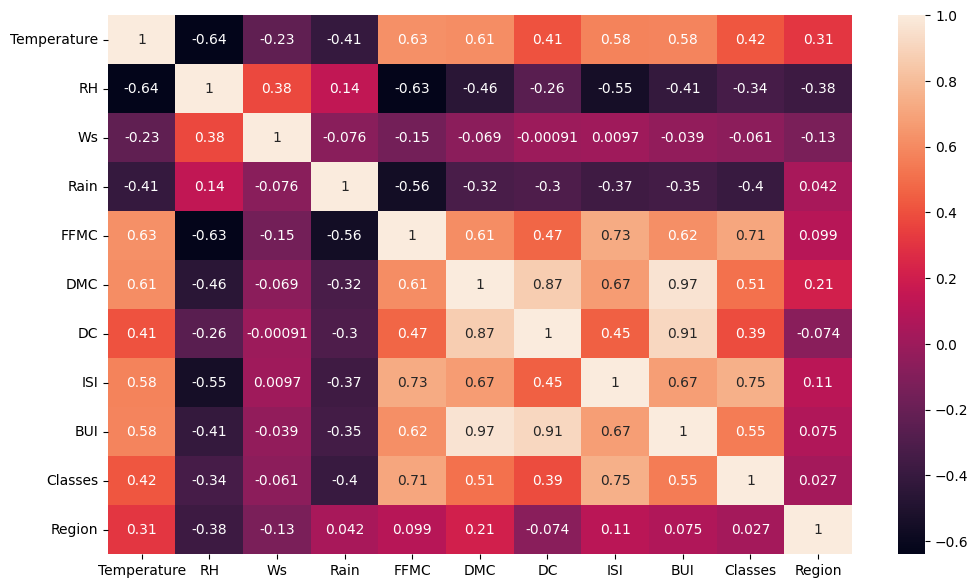

In [114]:
plt.figure(figsize=(12,7))
sns.heatmap(X_test.corr(), annot= True)

In [115]:
def correlation(dataset, threashold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threashold:
                col_name = corr_matrix.columns[i]
                col_corr.add(col_name)
    return col_corr

In [118]:
corr_features = correlation(X_train,0.80)

In [119]:
corr_features

{'BUI', 'DC'}

In [120]:
X_train.drop(corr_features, axis=1, inplace=True)
X_test.drop(corr_features, axis=1, inplace= True)
X_train.shape, X_test.shape

((194, 9), (49, 9))

In [111]:
from sklearn.preprocessing import StandardScaler

In [132]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [133]:
X_train_scaled

array([[-0.87563202,  0.21321832,  1.28577038, ..., -0.79648833,
        -1.14434427, -1.01036297],
       [ 0.22209084, -1.65484925,  0.14504117, ...,  1.88757476,
         0.8738629 ,  0.98974332],
       [ 1.5942444 , -1.25454906, -0.99568804, ..., -0.19488798,
         0.8738629 ,  0.98974332],
       ...,
       [-1.97335488,  0.947102  ,  0.52528424, ..., -1.0972885 ,
        -1.14434427, -1.01036297],
       [ 0.49652155, -0.18708188,  0.14504117, ...,  0.56868169,
         0.8738629 ,  0.98974332],
       [-0.60120131,  1.0138187 ,  2.04625653, ..., -0.88904223,
        -1.14434427, -1.01036297]])

In [136]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

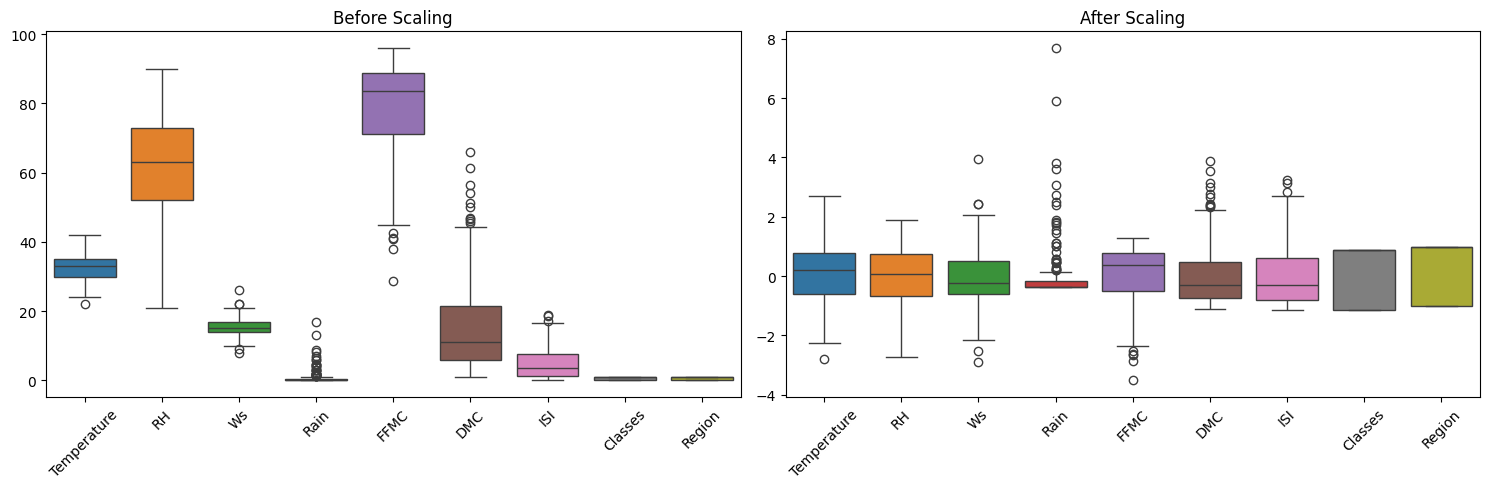

In [139]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title('Before Scaling')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title('After Scaling')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()